# AI-Based Career Recommendation System – EDA and Machine Learning Notebook

#### This notebook uses the synthetic dataset [AI-based Career Recommendation System](https://www.kaggle.com/datasets/adilshamim8/ai-based-career-recommendation-system/data) to:
- 1. Load and explore the dataset.
- 2. Perform extensive exploratory data analysis (EDA) to understand the data distribution.
- 3. Preprocess the data to prepare it for machine learning.
- 4. Build and evaluate a simple classification model to predict the recommended career.
- **Note:** The dataset is synthetic. The model and EDA steps serve as an example pipeline.

## Step 1: Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For preprocessing and modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Set style for seaborn
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("Career_Dataset_10000_Realistic.csv")
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,Aarohi Patel,36,PhD,Leadership;Communication;Market Research,Management;Science;Art,Product Manager,0.71
1,2,Aarohi Iyer,25,PhD,SQL;Reporting;Excel,Entrepreneurship;Management;Problem Solving,Data Analyst,0.87
2,3,Mohammad Singh,21,High School,SQL;Python;DSA,Research;Finance;Science,Software Developer,0.81
3,4,Vihaan Iyer,20,Master's,Management;Coordination;Leadership,Travel;Marketing;Entrepreneurship,Operations Manager,0.94
4,5,Sai Das,20,Bachelor's,Business Strategy;Finance;Leadership,Travel;Art;Technology,Entrepreneur,0.95


# Step 2: Data Overview
> Let's take a look at the basic structure, columns, and summary statistics of the dataset.

In [3]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (10000, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CandidateID           10000 non-null  int64  
 1   Name                  10000 non-null  object 
 2   Age                   10000 non-null  int64  
 3   Education             10000 non-null  object 
 4   Skills                10000 non-null  object 
 5   Interests             10000 non-null  object 
 6   Recommended_Career    10000 non-null  object 
 7   Recommendation_Score  10000 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 625.1+ KB


In [4]:
# Display summary statistics for numeric columns
df.describe()

,CandidateID,Age,Recommendation_Score
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,31.431500,0.844242
std,2886.89568,8.092642,0.084170
min,1.00000,18.000000,0.700000
25%,2500.75000,24.000000,0.770000
50%,5000.50000,31.000000,0.840000
75%,7500.25000,38.000000,0.920000
max,10000.00000,45.000000,0.990000


# Step 3: Exploratory Data Analysis (EDA)
## 3.1 Distribution of Age
> We'll look at the distribution of the `Age` column.

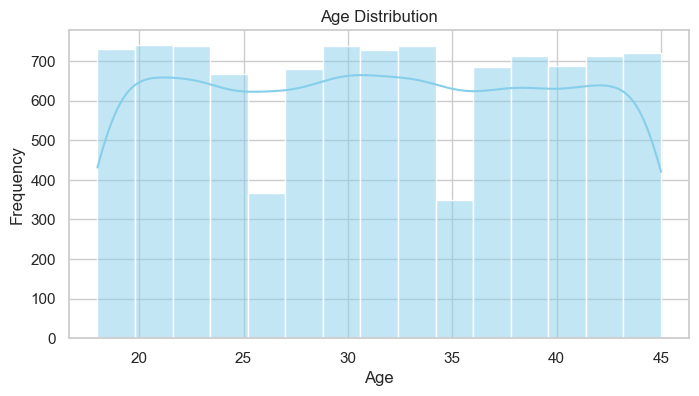

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=15, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 3.2 Count of Education Levels
> Let's examine how many candidates fall into each education category.

<Axes: xlabel='count', ylabel='Education'>

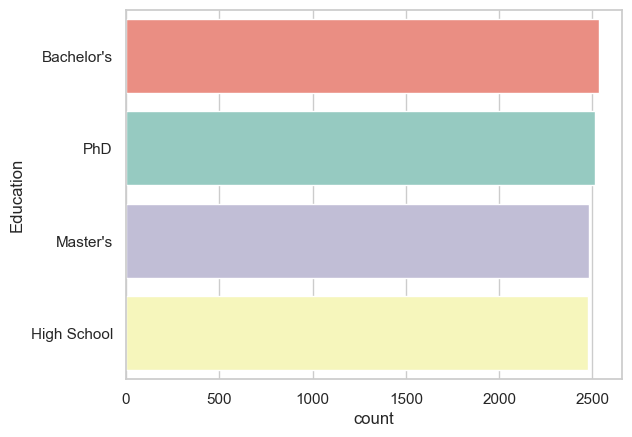

In [6]:
sns.countplot(
    y="Education",
    data=df,
    order=df["Education"].value_counts().index,
    hue="Education",
    palette="Set3",
    legend=False
)

## 3.3 Recommended Career Distribution
> A count plot for the `Recommended_Career` column to see the frequency of each career recommendation.

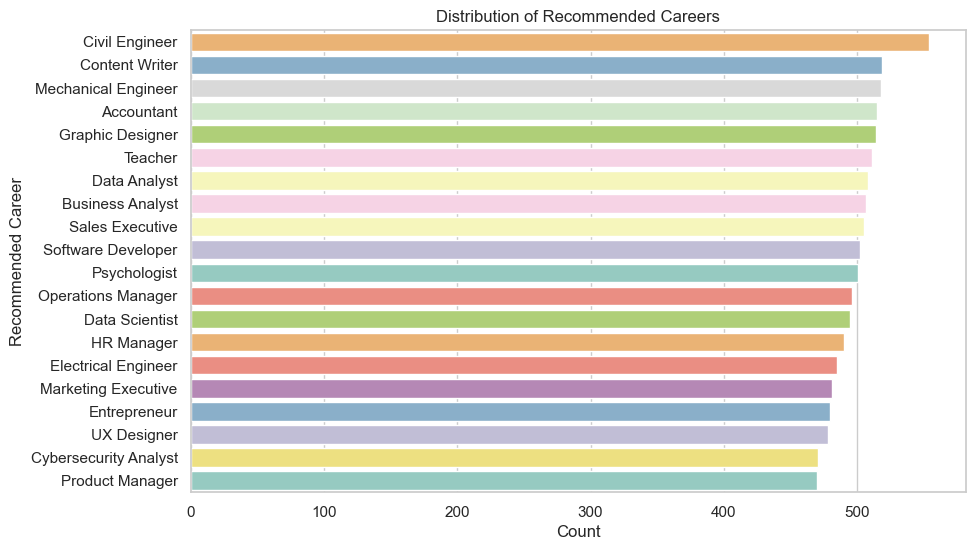

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    y="Recommended_Career",
    data=df,
    order=df["Recommended_Career"].value_counts().index,
    hue="Recommended_Career",   
    palette="Set3",
    legend=False                
)

plt.title("Distribution of Recommended Careers")
plt.xlabel("Count")
plt.ylabel("Recommended Career")
plt.show()

## 3.4 Recommendation Score Distribution
> Visualize the distribution of the `Recommendation_Score`.

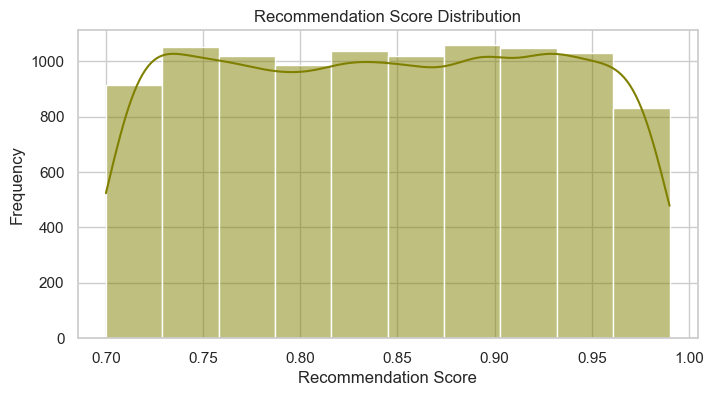

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Recommendation_Score'], bins=10, kde=True, color="olive")
plt.title("Recommendation Score Distribution")
plt.xlabel("Recommendation Score")
plt.ylabel("Frequency")
plt.show()

## 3.5 Skills and Interests Exploration 
> Since `Skills` and `Interests` are stored as semicolon-separated strings, we can explore the most common items. <br>
> We'll split the strings and count the frequency of each skill and interest.

In [9]:
# Function to split semicolon-separated values and count occurrences
def count_items(series):
    items = series.dropna().apply(lambda x: x.split(";"))
    flat_list = [item.strip() for sublist in items for item in sublist]
    return pd.Series(flat_list).value_counts()

In [10]:
# Count Skills
skills_count = count_items(df["Skills"])
print("Most common skills:\n", skills_count)

Most common skills:
 Communication      1653
Creativity         1026
Leadership          953
SQL                 849
Research            662
                   ... 
Algorithms          225
Problem Solving     221
C++                 215
DSA                 212
Java                208
Name: count, Length: 81, dtype: int64


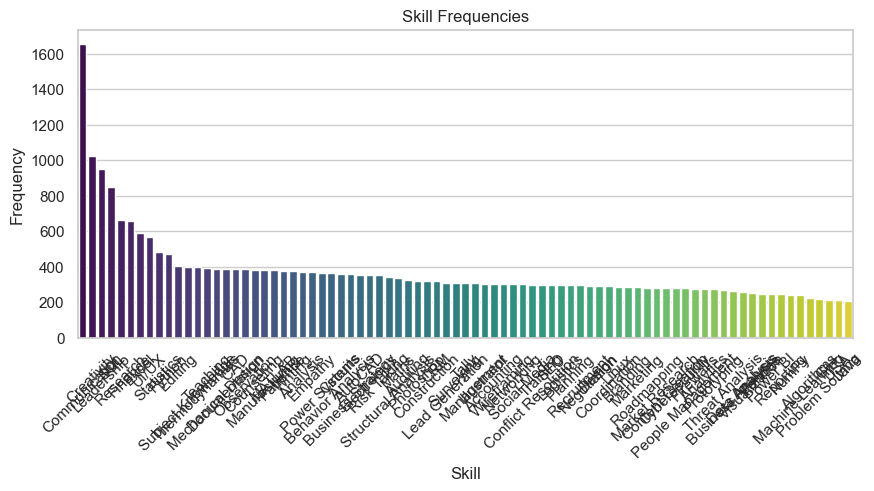

In [11]:
# Plot skills count
plt.figure(figsize=(10, 4))

sns.barplot(
    x=skills_count.index,
    y=skills_count.values,
    hue=skills_count.index,   
    palette="viridis",
    legend=False              
)

plt.xticks(rotation=45)
plt.title("Skill Frequencies")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()

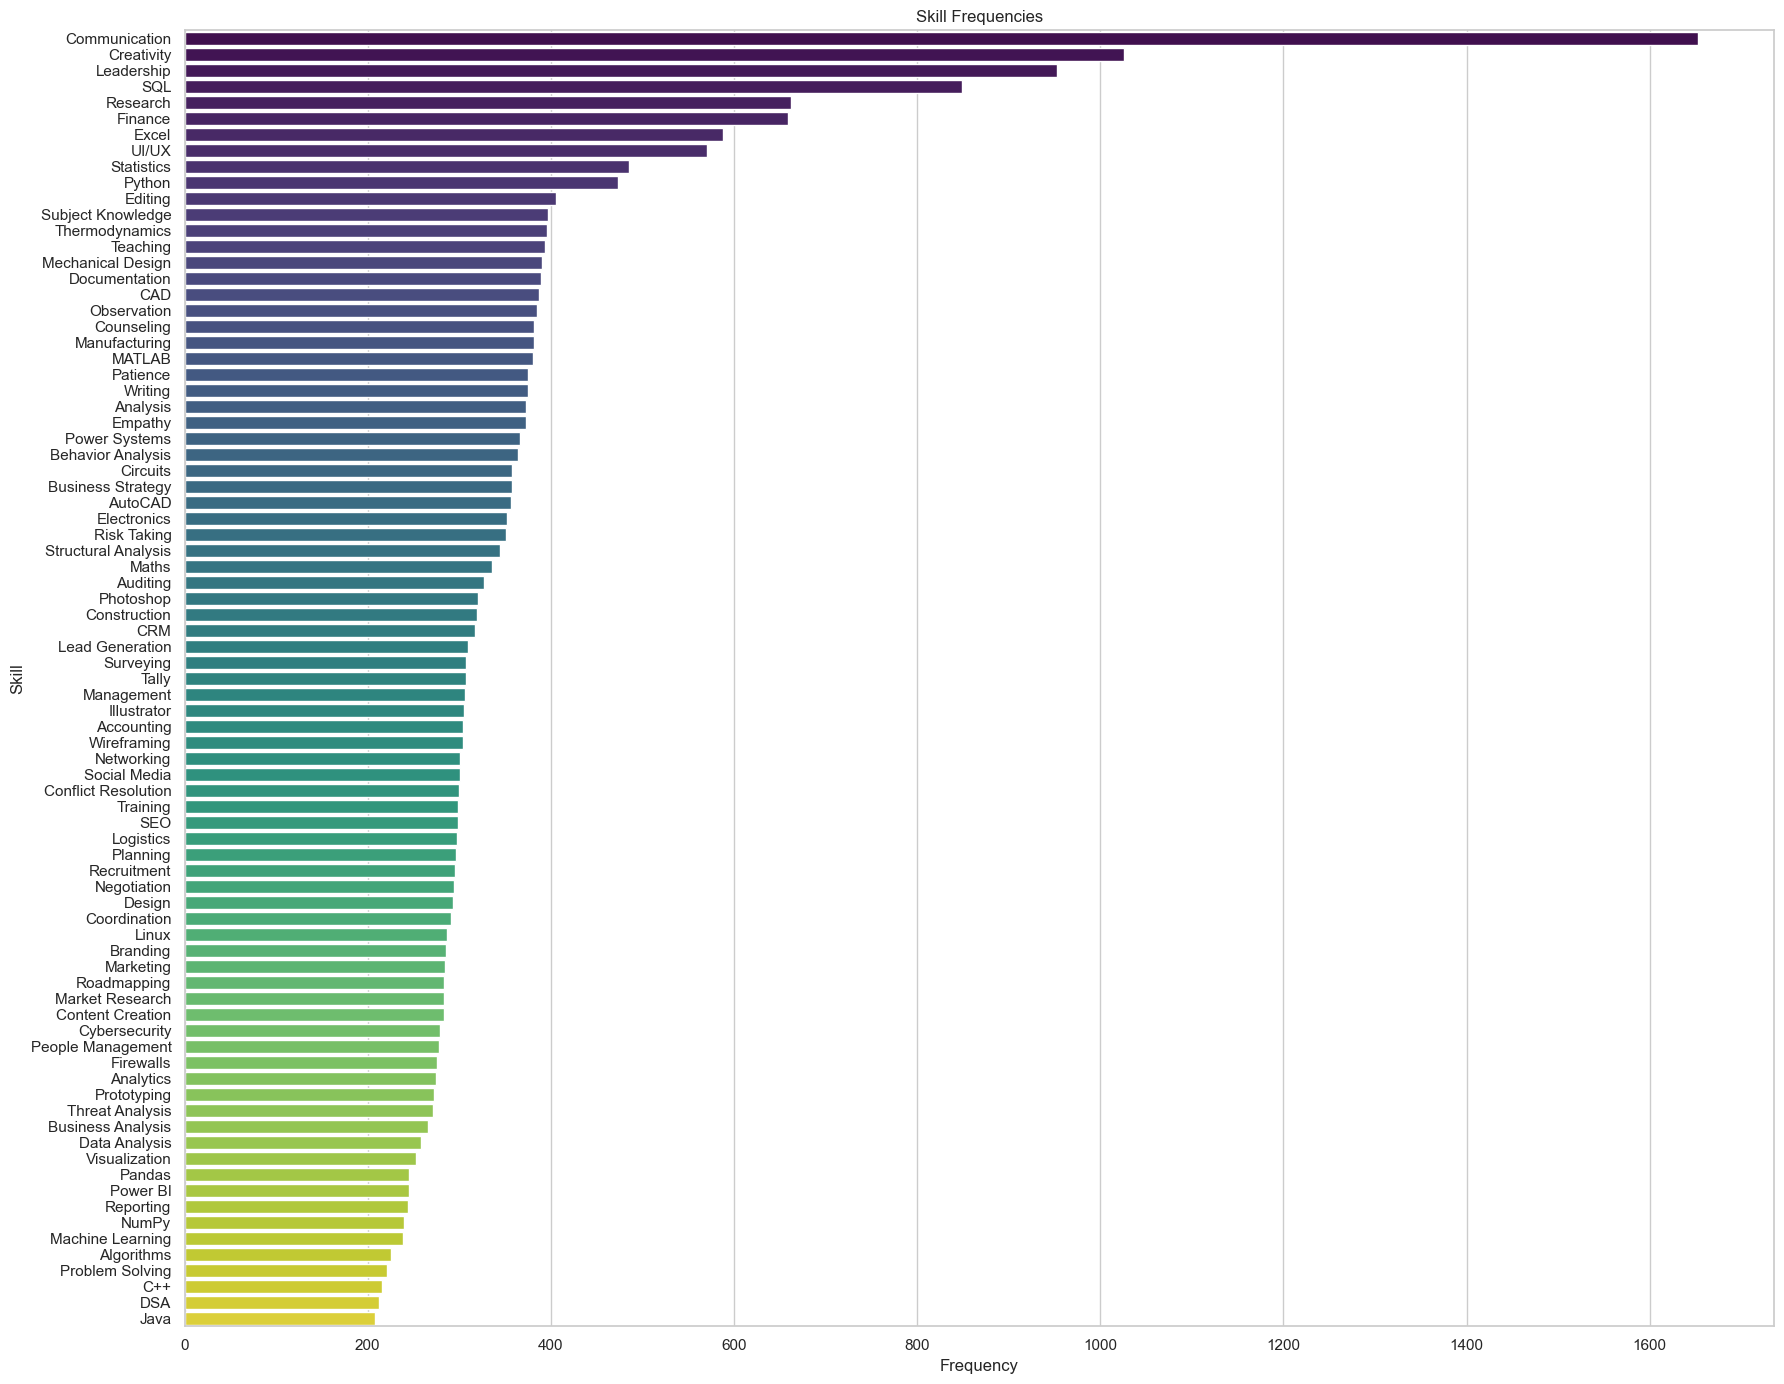

In [12]:
# Plot as horizontal bars with more vertical space
plt.figure(figsize=(18, 14))

sns.barplot(
    x=skills_count.values,
    y=skills_count.index,
    hue=skills_count.index,   
    palette="viridis",
    legend=False              
)

plt.title("Skill Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [13]:
# Count Interests
interests_count = count_items(df["Interests"])
print("Most common interests:\n", interests_count)

Most common interests:
 Marketing           2371
Science             2342
Teaching            2339
Management          2332
Research            2330
Travel              2328
Problem Solving     2312
Art                 2300
Finance             2293
Technology          2285
Public Speaking     2284
Entrepreneurship    2254
Design              2230
Name: count, dtype: int64


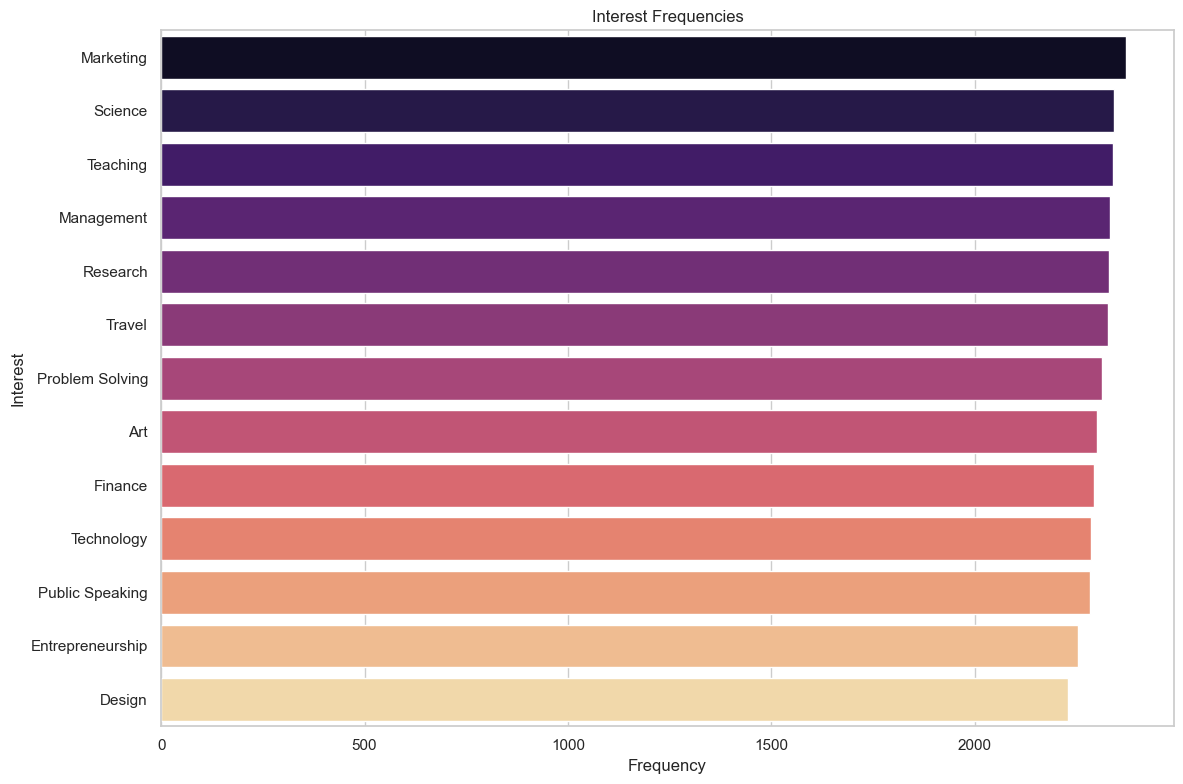

In [14]:
# Plot interests count as horizontal bars
plt.figure(figsize=(12, 8))

sns.barplot(
    x=interests_count.values,
    y=interests_count.index,
    hue=interests_count.index,   
    palette="magma",
    legend=False                 
)

plt.title("Interest Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Interest")
plt.tight_layout()
plt.show()

1. LOAD DATA

In [15]:
# Select features and target variable
df["Skills"] = df["Skills"].fillna("")
df["Interests"] = df["Interests"].fillna("")

df["Combined_Text"] = df["Skills"].astype(str) + " ; " + df["Interests"].astype(str)
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score,Combined_Text
0,1,Aarohi Patel,36,PhD,Leadership;Communication;Market Research,Management;Science;Art,Product Manager,0.71,Leadership;Communication;Market Research ; Man...
1,2,Aarohi Iyer,25,PhD,SQL;Reporting;Excel,Entrepreneurship;Management;Problem Solving,Data Analyst,0.87,SQL;Reporting;Excel ; Entrepreneurship;Managem...
2,3,Mohammad Singh,21,High School,SQL;Python;DSA,Research;Finance;Science,Software Developer,0.81,SQL;Python;DSA ; Research;Finance;Science
3,4,Vihaan Iyer,20,Master's,Management;Coordination;Leadership,Travel;Marketing;Entrepreneurship,Operations Manager,0.94,Management;Coordination;Leadership ; Travel;Ma...
4,5,Sai Das,20,Bachelor's,Business Strategy;Finance;Leadership,Travel;Art;Technology,Entrepreneur,0.95,Business Strategy;Finance;Leadership ; Travel;...


2. TRAIN / TEST SPLIT

In [16]:
X = df[["Age", "Education", "Combined_Text"]]
y = df["Recommended_Career"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 8000, Test size: 2000


3. PREPROCESSING PIPELINE

In [17]:
text_features = ["Combined_Text"]
numeric_features = ["Age"]
cat_features = ["Education"]

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(
            max_features=1500,
            token_pattern=r"[^;]+",     # treat each skill/interest as a token
            lowercase=True
        ), "Combined_Text"),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ["Education"]),
        ("scaler", StandardScaler(), ["Age"])
    ],
    sparse_threshold=0.3
    )

model

In [18]:
model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    n_jobs=-1,
    max_depth=None
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", model)
])

Train Model

In [19]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=1500,
                                                                  token_pattern='[^;]+'),
                                                  'Combined_Text'),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education']),
                                                 ('scaler', StandardScaler(),
                                                  ['Age'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=250, n_jobs=-1,
                                        random_state=42))])

Evaluate

In [20]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.9995

Classification Report:
                       precision    recall  f1-score   support

           Accountant       1.00      1.00      1.00       103
     Business Analyst       1.00      1.00      1.00       101
       Civil Engineer       1.00      1.00      1.00       111
       Content Writer       1.00      1.00      1.00       104
Cybersecurity Analyst       1.00      1.00      1.00        94
         Data Analyst       1.00      1.00      1.00       102
       Data Scientist       1.00      1.00      1.00        99
  Electrical Engineer       1.00      1.00      1.00        97
         Entrepreneur       1.00      1.00      1.00        96
     Graphic Designer       1.00      0.99      1.00       103
           HR Manager       1.00      1.00      1.00        98
  Marketing Executive       1.00      1.00      1.00        96
  Mechanical Engineer       1.00      1.00      1.00       104
   Operations Manager       1.00      1.00      1.00        99
      

Save Pipeline

In [21]:
joblib.dump(pipeline, "career_recommender_model.joblib")

print("\nModel saved as career_recommender_model.joblib")


Model saved as career_recommender_model.joblib


DEFINE PREDICTION FUNCTION

In [22]:
import joblib
import numpy as np
import pandas as pd

pipeline = joblib.load("career_recommender_model.joblib")

def predict_top_3_careers(age, education, skills_list, interests_list):
    combined_text = ";".join(skills_list) + ";" + ";".join(interests_list)

    # Convert into DataFrame
    user_df = pd.DataFrame([{
        "Age": age,
        "Education": education,
        "Combined_Text": combined_text
    }])

    # Predict proba
    proba = pipeline.predict_proba(user_df)[0]
    classes = pipeline.classes_

    # Top 3 indices
    top3_idx = np.argsort(proba)[-3:][::-1]

    # Return tuples [(career, probability), ...]
    return [(classes[i], float(proba[i])) for i in top3_idx]


In [23]:
results = predict_top_3_careers(
    age=25,
    education="Bachelor's",
    skills_list=["Python", "Data Analysis", "Machine Learning", "Critical Thinking"],
    interests_list=["Technology", "Data Science", "Innovation"]
)

print("\nExample user prediction (Top 3):")
for career, prob in results:
    print(f"- {career} ({prob:.2f})")



Example user prediction (Top 3):
- Data Scientist (0.94)
- Software Developer (0.05)
- Product Manager (0.00)


In [24]:
import sklearn
print(sklearn.__version__)

1.6.1
